# Metacatalog query browser

Browse Parquet catalogs under any discovered catalog tree under `CATALOG_ROOT`
(per-hour sources, LST-merged bands, and the global metacatalog). Use the
**Catalog directory** selector to switch trees, then pick a Parquet file and a
**HiPS survey** for the sky view. Inspect tables in a sortable/filterable grid,
find the nearest source to a sky coordinate, and — when viewing the
**metacatalog** — click a row to rematch that `meta_id` into LST/sources members
with consistency plots. Row clicks update the nearest-source coordinate box.
The first table row is selected with a **HiPS** overlay by default (refreshes on pan/zoom).
Click the sky view to select the nearest in-FOV `meta_id`. Plot per-band spectral flux and the stored Taylor model
for the selected row.

Optional config filters (config cell): `QUALITY_FLAG_MASK` (bitmask) and
`RADIO_QA_FILTER` (boolean Series / Index / labels / pandas query string). A string
seeds the browser **RADIO_QA_FILTER** box — edit and **Apply filter** without reloading
(e.g. `n_assoc_NVSS >= 1` when browsing `metacatalog_radio.parquet`).

Launch with `jupyter lab` (or your usual kernel that has `lwa-catalog[viz]`).
**Run cells in order.**

For classical Mahalanobis outlier scoring on a filtered metacatalog, see
`anomaly_detection.ipynb`.

A **Forced Photometry** section at the bottom uses `meta_id` / `source_file` from **Load trace**, resolves FITS via `FITS_ROOT`/`FITS_GLOB` (basename index), and targets a constrained Astropy `Gaussian2D` fit (option C; no PyBDSF re-run).


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import panel as pn

from lwa_catalog.catalog_index import (
    DEFAULT_DISPLAY_COLUMN_PREFS_PATH,
    DEFAULT_DISPLAY_COLUMNS,
    apply_quality_mask,
    discover_catalog_dirs,
    load_metacatalog_frame as _load_metacatalog_frame,
)
from lwa_catalog.constants import SUBBAND_REF_FREQ_MHZ
from lwa_catalog.paths import CatalogLayout

# --- user configuration ---------------------------------------------------
CATALOG_ROOT = Path("/fast/claw")
DEFAULT_CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband2")

CATALOG_DIRS = discover_catalog_dirs(CATALOG_ROOT)
_default = DEFAULT_CATALOG_DIR.resolve()
if _default not in CATALOG_DIRS:
    CATALOG_DIRS = sorted({_default, *CATALOG_DIRS})
DEFAULT_CATALOG_DIR = _default if _default in CATALOG_DIRS else CATALOG_DIRS[0]

# HiPS tiles load in your web browser (not the Jupyter kernel).
# HIPS_LIST_SERVER — survey names from ``cgi-bin/list-hips.py`` (dropdown; kernel fetch).
# HIPS_SERVER — tile base URL passed to Aladin (browser fetch; can differ from list host).
# If the list fetch fails, scans the selected catalog directory for HiPS ``properties`` dirs.
# Example: list from pipeline, serve coadd tiles locally:
#   ssh -L 3005:lwacalim10:3005 lwacalim09
#   python -m http.server 8000 --directory /fast/claw/metacatalog_coadd2
#   HIPS_LIST_SERVER = "http://localhost:3005"
#   HIPS_SERVER = "http://localhost:8000"
HIPS_LIST_SERVER = "http://lwacalim10:3005"  # or http://localhost:3005 when SSH-tunneled
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = (
    "Blue_I_deep_Taper_Robust-0.75_pbcorr_coadd_mosaic_jysr_feather_allsky_20241218-20250823_N023.hips"
)
SKY_FOV_DEG = 7
HIPS_VIEW_HEIGHT = 500
OVERLAY_MAX_SOURCES_DEFAULT = 500
OVERLAY_MAX_SOURCES_BOUNDS = (100, 1000)

TABLE_HEIGHT = 350
TABLE_PAGE_SIZE = 40
DEFAULT_N_NEAREST = 3
MAX_TABLE_COLUMNS = 40  # keep Tabulator responsive for wide metacatalog rows

# Default metacatalog row filter (quality_flag & 33267 == 0); no-op when quality_flag is absent.
# Bits: HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE
QUALITY_FLAG_MASK = 98803  # set None to keep all rows

# Optional row subset after quality mask (useful for metacatalog_radio.parquet).
# None | boolean Series aligned to index | Index | label array | pandas query string.
# A string seeds the CatalogBrowser text box; edit/apply it interactively without reloading.
# Examples:
# RADIO_QA_FILTER = None
# RADIO_QA_FILTER = "n_assoc_NVSS >= 1"
# RADIO_QA_FILTER = "n_assoc_VLASS >= 1 and Total_flux_NVSS > 0.05"
# RADIO_QA_FILTER = "spec_model_chi2_red < 2"
RADIO_QA_FILTER = None


def load_metacatalog_frame(
    layout: CatalogLayout,
    *,
    prefer_spectral: bool = True,
    ) -> pd.DataFrame:
    """Read the preferred metacatalog Parquet and apply ``QUALITY_FLAG_MASK`` by default."""
    return _load_metacatalog_frame(
        layout,
        prefer_spectral=prefer_spectral,
        quality_mask=QUALITY_FLAG_MASK,
    )


def apply_quality_mask_if_configured(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the default quality bitmask when enabled and ``quality_flag`` is present."""
    return apply_quality_mask(df, QUALITY_FLAG_MASK)


def apply_catalog_row_filters(df: pd.DataFrame) -> pd.DataFrame:
    """Apply ``QUALITY_FLAG_MASK`` only.

    ``RADIO_QA_FILTER`` is applied by ``CatalogBrowser`` (interactive string box, or
    a non-string config value on first publish).
    """
    return apply_quality_mask_if_configured(df)


# Preferred column order when present (others follow alphabetically).
# Overridden at runtime by DISPLAY_COLUMN_PREFS if that file exists.
PREFERRED_COLUMNS = DEFAULT_DISPLAY_COLUMNS
DISPLAY_COLUMN_PREFS = DEFAULT_DISPLAY_COLUMN_PREFS_PATH

SPEC_COLUMN_PREFIX = "spec_"
SPEC_REF_FREQ_MHZ = SUBBAND_REF_FREQ_MHZ

pn.extension("tabulator", throttled=True)


## Available catalog files

Inventory of every `*.parquet` under the default catalog tree (`DEFAULT_CATALOG_DIR`),
classified by artifact kind. The inventory table below refreshes when you change
**Catalog directory** in the browser.


In [2]:
from lwa_catalog.catalog_index import (
    classify_catalog,
    inventory_catalogs,
    is_metacatalog_parquet,
)

catalog_index = inventory_catalogs(DEFAULT_CATALOG_DIR)
print(f"{len(catalog_index)} Parquet files in {DEFAULT_CATALOG_DIR}")
print(f"Discovered {len(CATALOG_DIRS)} catalog trees under {CATALOG_ROOT}")
print(catalog_index["kind"].value_counts().to_string())

inventory_table = pn.widgets.Tabulator(
    catalog_index.drop(columns=["path"]),
    pagination="local",
    page_size=25,
    height=320,
    sizing_mode="stretch_width",
    layout="fit_data_table",
    header_filters=True,
    show_index=False,
    disabled=True,
    sortable=True,
    selectable=1,
)
inventory_table


348 Parquet files in /fast/claw/metacatalog_coaddR-0.75_subband2
Discovered 6 catalog trees under /fast/claw
kind
sources        330
lst_merged      15
metacatalog      3


Tabulator(disabled=True, header_filters=True, height=320, page_size=25, pagination='local', show_index=False, sizing_mode='stretch_width', value=              ...)

## Select a table, browse rows, load sky / trace / nearest

1. Choose a **Catalog directory**, then pick a **Catalog file** (or click a row in the inventory table).
2. Use **Display columns** to choose which fields appear in the browse table.
3. The first browse-table row is selected and its sky overlay loads by default. Use the action buttons below the table:
   - **Load sky view** — center HiPS and draw overlays for the **selected** row of the **selected Parquet only**
   - **Sky click** — always on after **Load sky view**; picks the nearest in-FOV `meta_id`, draws a **gold** cross (+ thick ellipse), updates the status line under the sky controls and the `meta_id` field (gold border). Use **Plot spectrum** / **Load trace** as usual
   - **Load trace** — rematch LST / per-hour sources and update the tables and plots below (does not change the sky overlay)
   - **Load nearest** — find neighbors around the selected row's coordinates
   - **Plot spectrum** (below the sky view) — LWA + survey (VLSSR/NVSS/VLASS) fluxes when present, with Taylor model for the selected row
4. Trace, nearest, and spectrum do **not** run automatically on row click (keeps the browser responsive).
5. **Save sky PNG** writes a quick QA screenshot under `<catalog-dir>/sky_screenshots/`.
6. **RADIO_QA_FILTER** (below the load header) accepts a pandas query string — e.g. `n_assoc_NVSS >= 1`. Click **Apply filter** to subset the loaded table (and sky overlay); **Clear** restores all quality-cleared rows without reloading the Parquet.


<IPython.core.display.Javascript object>

CatalogBrowser(band='all', catalog_dir='/fast/claw/metacatalog_coaddR-0.75_subband2', catalog_file='metacatalog_spectral.parquet', coordinate='252.881141 4.626243', display_columns=['meta_id', 'RA', 'DEC', 'bands_present', 'origin_band', 'n_lst_contributions'], kind='all', lst_hour='all', max_sources=500, meta_id=1248, n_nearest=3, name='CatalogBrowser00124', radio_qa_filter='', show_overlay=True)
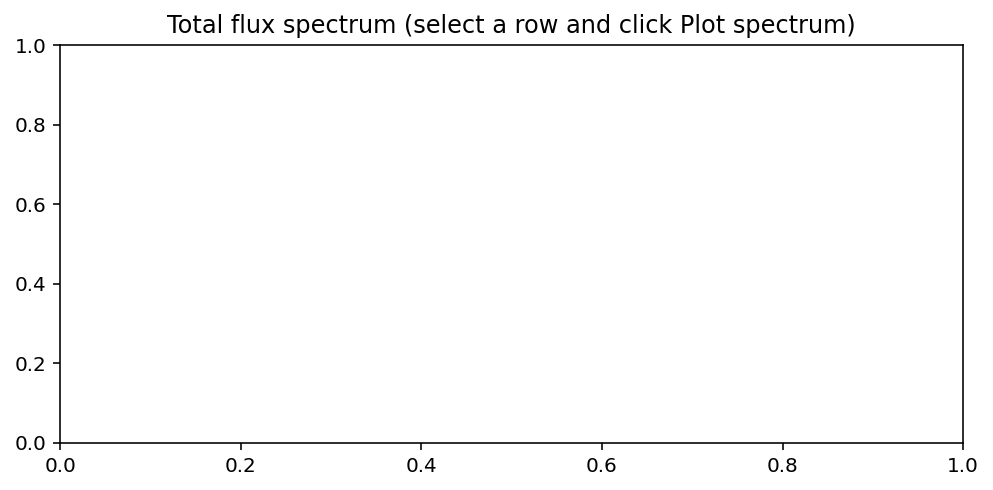
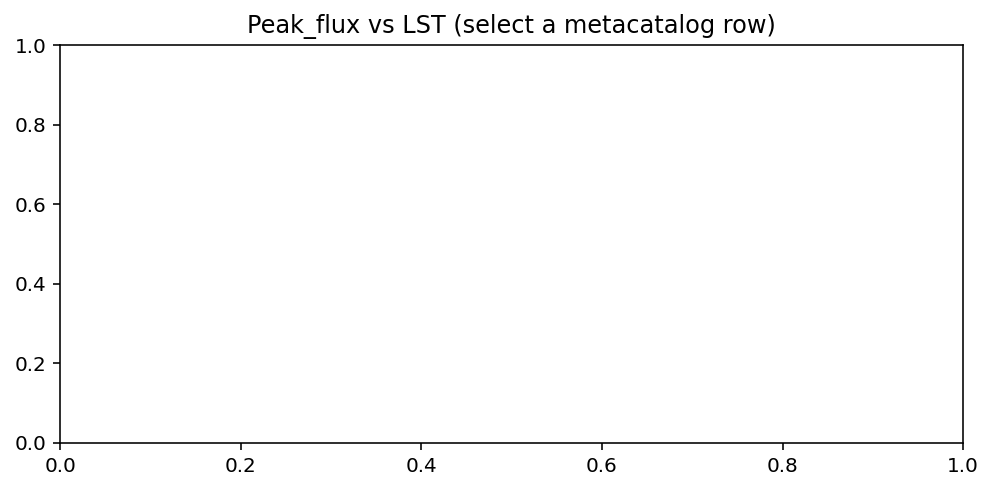
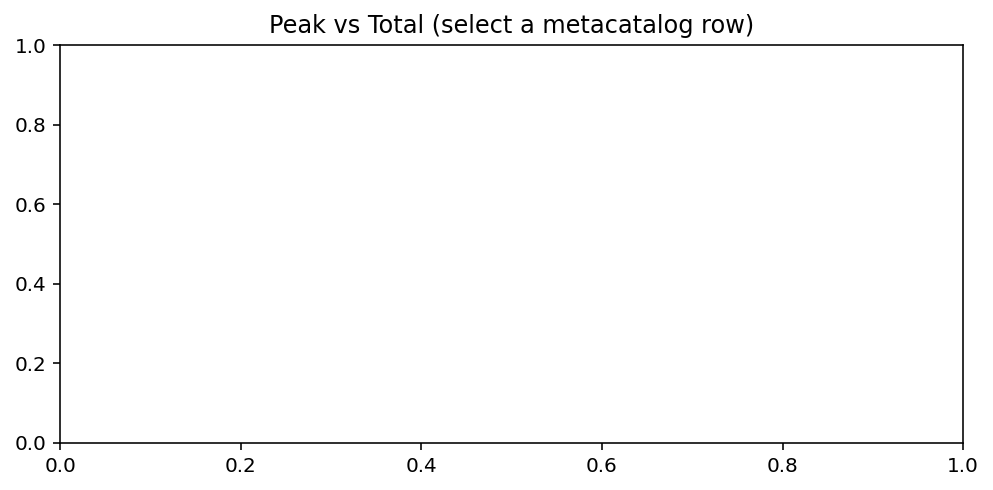
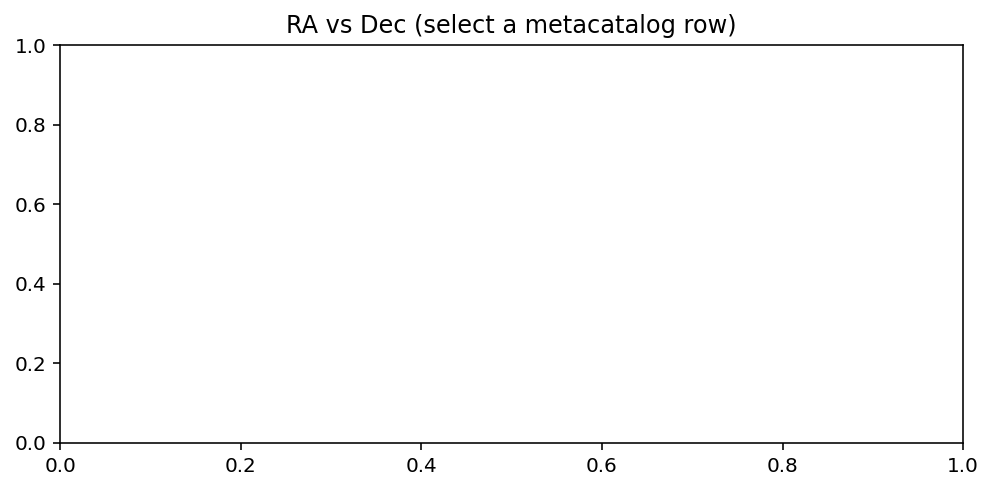
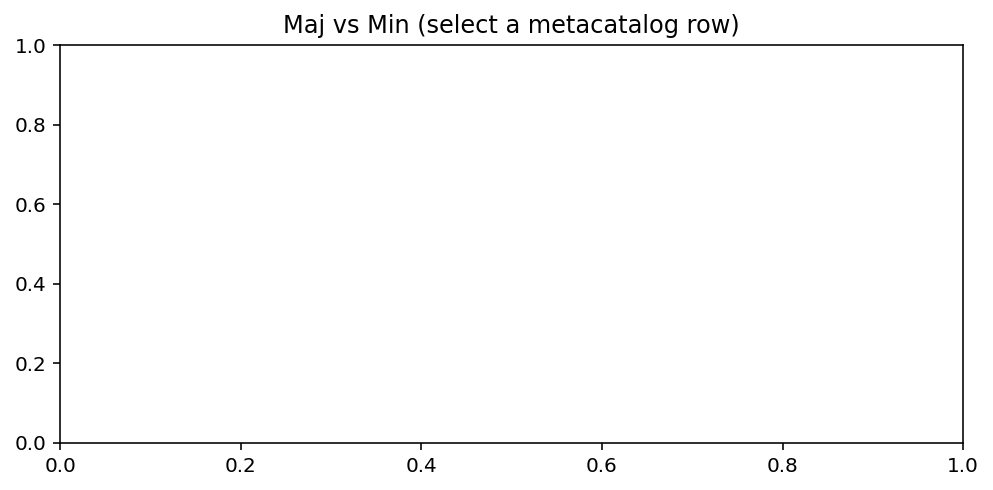

In [3]:
from lwa_catalog.viz import CatalogBrowser, CatalogBrowserConfig

BROWSER_CONFIG = CatalogBrowserConfig(
    catalog_dirs=tuple(str(p) for p in CATALOG_DIRS),
    default_catalog_dir=str(DEFAULT_CATALOG_DIR),
    hips_list_server=HIPS_LIST_SERVER,
    hips_server=HIPS_SERVER,
    default_hips_survey=DEFAULT_HIPS_SURVEY,
    sky_fov_deg=float(SKY_FOV_DEG),
    hips_view_height=int(HIPS_VIEW_HEIGHT),
    overlay_max_sources_default=int(OVERLAY_MAX_SOURCES_DEFAULT),
    overlay_max_sources_bounds=tuple(OVERLAY_MAX_SOURCES_BOUNDS),
    table_height=int(TABLE_HEIGHT),
    table_page_size=int(TABLE_PAGE_SIZE),
    default_n_nearest=int(DEFAULT_N_NEAREST),
    max_table_columns=int(MAX_TABLE_COLUMNS),
    radio_qa_filter=RADIO_QA_FILTER,
    quality_flag_mask=QUALITY_FLAG_MASK,
    preferred_columns=tuple(PREFERRED_COLUMNS),
    display_column_prefs_path=DISPLAY_COLUMN_PREFS,
    spec_column_prefix=SPEC_COLUMN_PREFIX,
    spec_ref_freq_mhz=float(SPEC_REF_FREQ_MHZ),
)

_prev_browser = globals().get("_catalog_browser")
if isinstance(_prev_browser, CatalogBrowser):
    _prev_browser.close_mpl_figures()

_catalog_browser = CatalogBrowser(
    catalog_index,
    config=BROWSER_CONFIG,
    inventory_table=inventory_table,
)
browser = _catalog_browser


def _on_inventory_select(event) -> None:
    if not inventory_table.selection:
        return
    row = inventory_table.value.iloc[int(inventory_table.selection[0])]
    browser.select_file(str(row["file"]))


inventory_table.param.watch(_on_inventory_select, "selection")
browser


## Forced Photometry

Constrained elliptical-Gaussian remeasurement on a FITS cutout (**option C**):
fix peak (and small centroid / optional size shifts) around catalog guesses from
the **source trace** rematch.

### Inputs (Mode A — wired below)

Pick a `meta_id` and a `source_file` from **all discovered FITS** under
`FITS_ROOT`/`FITS_GLOB` whose LST has the meta_id RA/DEC at **elevation > 10°**
(`MIN_FORCED_ELEVATION_DEG`; same cut as quality `LOW_ELEVATION`). This includes hours **missed by
PyBDSF** (not limited to the source-trace rematch list). Rematch hits are
preferred as the default selection and as shape/flux seeds when present;
otherwise seeds come from the metacatalog row (RA/DEC + Maj/Min/PA/Peak).
`source_file` is **basename only** — resolve via the discovery index
(fallback: `resolve_fits_slot(lst_hour, band)`).

### Approach (option C)

Use Astropy `modeling.models.Gaussian2D` + a fitter (`LevMarLSQFitter` or
`scipy.optimize`) on a cutout from `prepare_hdu`:

- **Initial guesses:** `RA`/`DEC`, `Maj`/`Min`/`PA`, `Peak_flux` from the rematch
  `source_matches` row when that FITS was detected; otherwise from the metacatalog
  (band-suffixed columns when needed). Same Maj/Min FWHM / PA-from-North geometry
  as `_gaussian_healpix`.
- **Free parameters (typical):** amplitude; optional tight bounds on `x_stddev` /
  `y_stddev` / `theta`. Centroid (`x_mean`/`y_mean`) is free within a few pixels by
  default, or locked to the **metacatalog** RA/DEC via **Fix position to metacatalog
  RA/DEC**.
- **Fixed or tightly bounded:** shape from the GAUL row or restoring beam when the
  S/N is low.
- **Outputs:** `forced_Peak_flux`, integrated flux from the model, ΔRA/ΔDec,
  optional residual RMS; show data / model / residual stamps.

Fit logic lives in `lwa_catalog.analyze.forced_photometry`. The cell below runs option **C** (`Gaussian2D` + `LevMarLSQFitter` + const
background), shows the result table, then **input / model / residual** cutouts.
**PyBDSF is not re-run** here.


Column
    [0] Markdown(str)
    [1] Row(align='end')
        [0] IntInput(label='meta_id', name='meta_id', start=0, value=1248, width=140)
        [1] Select(label='source_file', name='source_file', options=['18MHz_I_deep_Taper_Robus...], value='18MHz_I_deep_Taper_Robust..., width=420)
        [2] Button(label='Refresh inputs', name='Refresh inputs', width=150)
    [2] Row(align='center')
        [0] Checkbox(label='Fix position t..., name='Fix position t..., width=280)
        [1] Button(button_type='primary', color='primary', label='Run forced photometry', name='Run forced photometry', width=180)
    [3] Markdown(str)
    [4] Markdown(str)
    [5] Tabulator(disabled=True, height=160, show_index=False, sizing_mode='stretch_width', value=Empty DataFrame
Columns: [...)
    [6] Markdown(str)
    [7] Matplotlib(Figure, sizing_mode='stretch_width', tight=True)
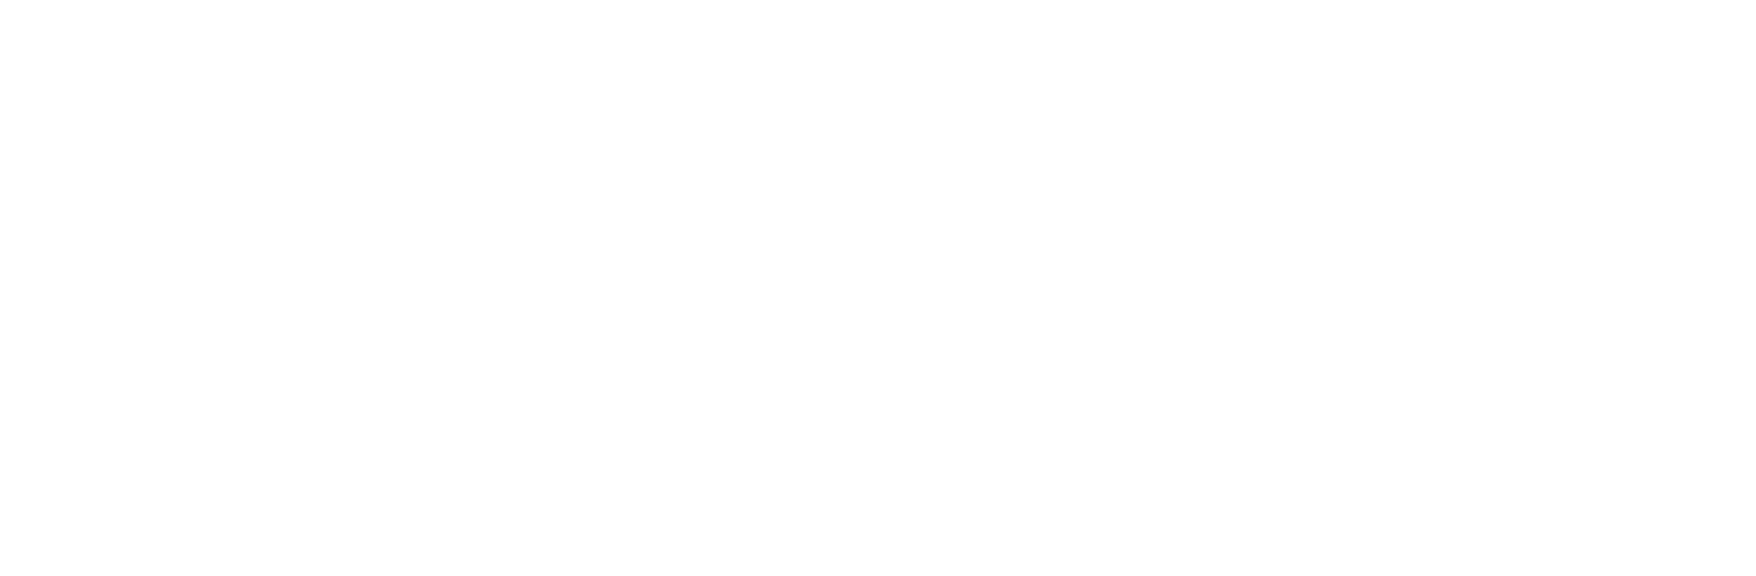

In [4]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import panel as pn
from astropy.io import fits

from lwa_catalog.analyze import rematch_meta_source
from lwa_catalog.analyze.forced_photometry import (
    ForcedPhotometryConfig,
    discover_and_index_fits,
    filter_fits_by_elevation,
    fit_gaussian2d_cutout,
    plot_forced_cutouts,
    resolve_forced_fits_path,
    select_forced_seed_row,
    summarize_forced_photometry,
)
from lwa_catalog.create.detect import beam_from_header

# Same pattern as notebooks/ovro_lwa_metacatalog.ipynb — source_file is basename only.
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
FITS_GLOB: str | tuple[str, ...] = "??h_*MHz/*_I_deep_Taper_Robust-0.75*pbcorr*fits"

FP_CONFIG = ForcedPhotometryConfig(min_elevation_deg=10.0)

_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
_fits_discover_error: str | None = None
try:
    _discovered, _fits_by_name, _fits_meta_by_name = discover_and_index_fits(
        FITS_ROOT, _fits_patterns
    )
except Exception as _exc:  # noqa: BLE001 — surface in UI status
    _discovered, _fits_by_name, _fits_meta_by_name = [], {}, {}
    _fits_discover_error = str(_exc)

_fp_status = pn.pane.Markdown(
    "_Load a metacatalog, select a row, then refresh inputs below._"
)
_fp_meta_id_w = pn.widgets.IntInput(name="meta_id", value=0, start=0, width=140)
_fp_source_file_w = pn.widgets.Select(name="source_file", options=[], value=None, width=420)
_fp_refresh_btn = pn.widgets.Button(name="Refresh inputs", width=150)
_fp_fixed_pos_w = pn.widgets.Checkbox(
    name="Fix position to metacatalog RA/DEC",
    value=False,
    width=280,
)
_fp_run_btn = pn.widgets.Button(name="Run forced photometry", button_type="primary", width=180)
_fp_panels_pane = pn.pane.Matplotlib(
    plt.figure(figsize=(12, 3.8)),
    tight=True,
    sizing_mode="stretch_width",
)
_fp_result_table = pn.widgets.Tabulator(
    pd.DataFrame(),
    height=160,
    sizing_mode="stretch_width",
    disabled=True,
    show_index=False,
)
plt.close("all")


def _browser_metacatalog_and_layout():
    """Return ``(meta_df, layout)`` from CatalogBrowser, or ``(None, None)``."""
    br = globals().get("browser")
    if br is None:
        return None, None
    layout = getattr(br, "_layout", None)
    meta_df = None
    if hasattr(br, "_metacatalog_frame"):
        try:
            meta_df = br._metacatalog_frame()
        except Exception:
            meta_df = getattr(br, "_df", None)
    else:
        meta_df = getattr(br, "_df", None)
    if meta_df is None or not isinstance(meta_df, pd.DataFrame) or meta_df.empty:
        return None, layout
    return meta_df, layout


def _ensure_trace_for_meta_id(meta_id: int):
    """Return SourceTrace for *meta_id*, rematching when the loaded trace differs."""
    br = globals().get("browser")
    meta_id = int(meta_id)
    if br is not None:
        trace = getattr(br, "_trace", None)
        if (
            trace is not None
            and int(getattr(trace, "meta_id", -1)) == meta_id
            and getattr(trace, "source_matches", None) is not None
            and isinstance(trace.source_matches, pd.DataFrame)
            and not trace.source_matches.empty
        ):
            return trace

    meta_df, layout = _browser_metacatalog_and_layout()
    if meta_df is None or layout is None:
        raise ValueError(
            "Need a loaded CatalogBrowser metacatalog (and layout) to rematch "
            f"meta_id={meta_id}"
        )
    if "meta_id" not in meta_df.columns:
        raise ValueError("Loaded catalog has no meta_id column")
    if meta_id not in set(meta_df["meta_id"].dropna().astype(int)):
        raise ValueError(f"meta_id={meta_id} not found in loaded metacatalog")

    trace = rematch_meta_source(meta_df, layout, meta_id=meta_id)
    if br is not None:
        br._trace = trace
        try:
            br.meta_id = int(meta_id)
        except Exception:
            pass
    return trace


def _discovery_status_prefix() -> str:
    disc = (
        f"Discovered **{len(_fits_by_name)}** FITS under `{FITS_ROOT}` "
        f"(glob={list(_fits_patterns)})."
    )
    if _fits_discover_error:
        disc = f"**FITS discovery failed:** `{_fits_discover_error}`"
    return disc


def _meta_row_for_id(meta_id: int) -> pd.Series:
    """Return the metacatalog row for *meta_id* (trace cache, else browser table)."""
    meta_id = int(meta_id)
    br = globals().get("browser")
    if br is not None:
        trace = getattr(br, "_trace", None)
        if trace is not None and int(getattr(trace, "meta_id", -1)) == meta_id:
            meta_row = getattr(trace, "meta_row", None)
            if meta_row is not None:
                return meta_row

    meta_df, _layout = _browser_metacatalog_and_layout()
    if meta_df is None or "meta_id" not in meta_df.columns:
        raise ValueError(
            f"Need a loaded CatalogBrowser metacatalog to resolve meta_id={meta_id}"
        )
    hits = meta_df.loc[meta_df["meta_id"].dropna().astype(int) == meta_id]
    if hits.empty:
        raise ValueError(f"meta_id={meta_id} not found in loaded metacatalog")
    return hits.iloc[0]


def _rematch_source_matches(meta_id: int) -> pd.DataFrame:
    """Best-effort rematch rows (may be empty if trace/layout unavailable)."""
    try:
        trace = _ensure_trace_for_meta_id(meta_id)
    except Exception:
        return pd.DataFrame()
    sm = getattr(trace, "source_matches", None)
    if sm is None or not isinstance(sm, pd.DataFrame) or sm.empty:
        return pd.DataFrame()
    return sm


def _finite(row: pd.Series, key: str, default: float = float("nan")) -> float:
    if key not in row.index or pd.isna(row.get(key)):
        return float(default)
    try:
        return float(row[key])
    except (TypeError, ValueError):
        return float(default)


def _apply_fits_options(meta_row: pd.Series, *, meta_id: int) -> None:
    """Fill ``source_file`` from discovered FITS above ``FP_CONFIG.min_elevation_deg``."""
    try:
        ra = float(meta_row["RA"])
        dec = float(meta_row["DEC"])
    except (KeyError, TypeError, ValueError) as exc:
        _fp_source_file_w.options = []
        _fp_source_file_w.value = None
        _fp_status.object = (
            f"{_discovery_status_prefix()}<br/>"
            f"**meta_id={meta_id} missing finite RA/DEC:** `{exc}`"
        )
        return
    if not (np.isfinite(ra) and np.isfinite(dec)):
        _fp_source_file_w.options = []
        _fp_source_file_w.value = None
        _fp_status.object = (
            f"{_discovery_status_prefix()}<br/>"
            f"**meta_id={meta_id} missing finite RA/DEC.**"
        )
        return

    fits_list = filter_fits_by_elevation(
        _discovered, ra, dec, min_elevation_deg=FP_CONFIG.min_elevation_deg
    )
    files = sorted({meta.path.name for meta in fits_list})
    if not files:
        _fp_source_file_w.options = []
        _fp_source_file_w.value = None
        _fp_status.object = (
            f"{_discovery_status_prefix()}<br/>"
            f"_No discovered FITS with elev > {FP_CONFIG.min_elevation_deg:g}° "
            f"for meta_id={meta_id} at RA={ra:.4f}, Dec={dec:.4f}._"
        )
        return

    rematch = _rematch_source_matches(meta_id)
    rematch_names: set[str] = set()
    if not rematch.empty and "source_file" in rematch.columns:
        rematch_names = {
            Path(str(x)).name for x in rematch["source_file"].dropna().astype(str)
        }
    n_traced = sum(1 for f in files if f in rematch_names)

    _fp_source_file_w.options = files
    if _fp_source_file_w.value not in files:
        preferred = sorted(rematch_names & set(files))
        _fp_source_file_w.value = preferred[0] if preferred else files[0]

    _fp_status.object = (
        f"{_discovery_status_prefix()}<br/>"
        f"Using **meta_id={meta_id}** at RA={ra:.5f}, Dec={dec:.5f} — "
        f"**{len(files)}** FITS above elev cut (elev > {FP_CONFIG.min_elevation_deg:g}°); "
        f"**{n_traced}** also in rematch/trace (PyBDSF hit). "
        "Missed hours use metacatalog RA/DEC + shape/flux seeds."
    )


def _refresh_forced_inputs(_event=None, *, sync_meta_from_browser: bool = True) -> None:
    """Refresh fit inputs for the active meta_id."""
    br = globals().get("browser")
    if sync_meta_from_browser and br is not None and getattr(br, "meta_id", None) is not None:
        _fp_meta_id_w.value = int(br.meta_id)

    mid = int(_fp_meta_id_w.value)
    try:
        meta_row = _meta_row_for_id(mid)
    except Exception as exc:
        _fp_source_file_w.options = []
        _fp_source_file_w.value = None
        _fp_status.object = (
            f"{_discovery_status_prefix()}<br/>**Could not resolve meta_id={mid}:** `{exc}`"
        )
        return
    try:
        _ensure_trace_for_meta_id(mid)
    except Exception:
        pass
    _apply_fits_options(meta_row, meta_id=mid)


def _on_meta_id_change(_event=None) -> None:
    _refresh_forced_inputs(sync_meta_from_browser=False)


def _selected_seed_row() -> pd.Series | None:
    mid = int(_fp_meta_id_w.value)
    name = _fp_source_file_w.value
    if name is None or str(name).strip() == "":
        return None
    name = Path(str(name)).name
    meta_info = _fits_meta_by_name.get(name)
    lst_hour = str(meta_info.lst_hour) if meta_info is not None else None
    band = str(meta_info.band) if meta_info is not None else None
    try:
        meta_row = _meta_row_for_id(mid)
    except Exception:
        return None
    return select_forced_seed_row(
        source_file=name,
        rematch=_rematch_source_matches(mid),
        meta_row=meta_row,
        lst_hour=lst_hour,
        band=band,
    )


def _on_run_forced(_event=None) -> None:
    meta_id = int(_fp_meta_id_w.value)
    try:
        _refresh_forced_inputs(sync_meta_from_browser=False)
    except Exception as exc:
        _fp_status.object = f"**Could not refresh inputs for meta_id={meta_id}:** `{exc}`"
        return
    row = _selected_seed_row()
    if row is None:
        _fp_status.object = (
            f"**No above-elevation FITS / seeds for meta_id={meta_id}.** "
            "Load a metacatalog, pick a valid meta_id, then **Refresh inputs**."
        )
        return
    source_file = (
        str(_fp_source_file_w.value) if _fp_source_file_w.value else str(row.get("source_file", ""))
    )
    name = Path(source_file).name
    meta_info = _fits_meta_by_name.get(name)
    lst_hour = (
        str(meta_info.lst_hour)
        if meta_info is not None
        else (str(row["lst_hour"]) if "lst_hour" in row.index and pd.notna(row.get("lst_hour")) else None)
    )
    band = (
        str(meta_info.band)
        if meta_info is not None
        else (str(row["band"]) if "band" in row.index and pd.notna(row.get("band")) else None)
    )
    try:
        fits_path = resolve_forced_fits_path(
            source_file,
            by_name=_fits_by_name,
            fits_root=FITS_ROOT,
            lst_hour=lst_hour,
            band=band,
        )
    except Exception as exc:
        _fp_status.object = f"**FITS resolve failed:** `{exc}`"
        return

    fixed_position = bool(_fp_fixed_pos_w.value)
    if fixed_position:
        try:
            meta_row = _meta_row_for_id(meta_id)
        except Exception as exc:
            _fp_status.object = f"**Need metacatalog RA/DEC to fix position:** `{exc}`"
            return
        ra = _finite(meta_row, "RA")
        dec = _finite(meta_row, "DEC")
        if not (np.isfinite(ra) and np.isfinite(dec)):
            _fp_status.object = "**Metacatalog row missing finite RA/DEC for fixed position.**"
            return
    else:
        ra = _finite(row, "RA")
        dec = _finite(row, "DEC")
        if not (np.isfinite(ra) and np.isfinite(dec)):
            _fp_status.object = "**Row missing finite RA/DEC.**"
            return

    maj = _finite(row, "Maj")
    minor = _finite(row, "Min")
    pa = _finite(row, "PA")
    peak = _finite(row, "Peak_flux")
    total = _finite(row, "Total_flux")
    try:
        bmaj, bmin, bpa = beam_from_header(fits.getheader(fits_path))
    except Exception:
        bmaj = bmin = bpa = float("nan")

    try:
        result = fit_gaussian2d_cutout(
            fits_path,
            ra_deg=ra,
            dec_deg=dec,
            maj_deg=maj,
            min_deg=minor,
            pa_deg=pa,
            peak_guess=peak,
            bmaj_deg=bmaj,
            bmin_deg=bmin,
            fixed_position=fixed_position,
            meta_id=meta_id,
            config=FP_CONFIG,
        )
        status = "ok"
    except Exception as exc:
        _fp_status.object = f"**Fit failed** for `{fits_path.name}`: `{exc}`"
        return

    fig = plot_forced_cutouts(result, title=fits_path.name)
    _fp_panels_pane.object = fig
    plt.close(fig)

    info = pd.DataFrame(
        [
            {
                "meta_id": meta_id,
                "source_file": source_file,
                "fits_path": str(fits_path),
                "lst_hour": lst_hour,
                "band": band,
                "RA": ra,
                "DEC": dec,
                "fixed_position": fixed_position,
                "Maj": maj,
                "Min": minor,
                "PA": pa,
                "Peak_flux": peak,
                "Total_flux": total,
                "BMAJ": bmaj,
                "BMIN": bmin,
                "BPA": bpa,
                "forced_Peak_flux": result.forced_Peak_flux,
                "forced_Total_flux": result.forced_Total_flux,
                "forced_RA": result.forced_RA,
                "forced_DEC": result.forced_DEC,
                "forced_resid_rms": result.forced_resid_rms,
                "forced_bkg": result.summary["forced_bkg"],
                "status": status,
                "fit_info": result.summary["fit_info"],
            }
        ]
    )
    _fp_result_table.value = info
    _fp_status.object = (
        f"**Option C fit OK** for `meta_id={meta_id}` / `{source_file}` → `{fits_path.name}`.<br/>"
        f"{summarize_forced_photometry(result)}."
    )


_fp_refresh_btn.on_click(lambda *_: _refresh_forced_inputs(sync_meta_from_browser=True))
_fp_run_btn.on_click(_on_run_forced)
_fp_meta_id_w.param.watch(_on_meta_id_change, "value")
_refresh_forced_inputs(sync_meta_from_browser=True)

pn.Column(
    pn.pane.Markdown(
        f"`FITS_ROOT = {FITS_ROOT}` · `FITS_GLOB = {FITS_GLOB!r}` · "
        f"indexed **{len(_fits_by_name)}** files · "
        f"elev > {FP_CONFIG.min_elevation_deg:g}° "
        "(library: `lwa_catalog.analyze.forced_photometry`)."
    ),
    pn.Row(_fp_meta_id_w, _fp_source_file_w, _fp_refresh_btn, align="end"),
    pn.Row(_fp_fixed_pos_w, _fp_run_btn, align="center"),
    _fp_status,
    pn.pane.Markdown("### Fit results"),
    _fp_result_table,
    pn.pane.Markdown("### Cutout: input · model · residual"),
    _fp_panels_pane,
)
